In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist.data_utils import load_data

In [1]:
# ----- K-Nearest Neighbor Implementation -----

In [2]:
class KNN:

    def train(self, X, y): # training data를 단순 memorizing
        
        self.X_train = X # (N, D): N개의 D차원 넘파이 데이터
        self.y_train = y # (N,): N개 데이터에 대한 class label

    
    def inference(self, X_test, k=1, dist_metric='dot'): # k개의 가까운 training sample에서 다수결 투표를 통해 class를 예측
        
        dists = self.compute_distance(X_test, dist_metric) # dist_metric: 어떤 방법으로 거리를 계산할 것인지. default는 dot-product
        y_pred = self.predict_labels(X_test, dists, k) # dists: compute_distance함수를 통해 계산된 거리
        return y_pred

    
    def compute_distance(self, X_test, dist_metric='l2'): # training data, test data 사이의 거리 계산

        if dist_metric=='dot': 
            sim = np.matmul(X_test, self.X_train.T)
            dists = -sim

        #elif dist_metric=='cos':
            # your code

        elif dist_metric=='l2':          
            sub = np.repeat(X_test, self.X_train.shape[0], axis=0) - np.tile(self.X_train, reps=[X_test.shape[0], 1])
            dists = np.sqrt(np.sum(sub*sub,axis=1)).reshape(X_test.shape[0],self.X_train.shape[0])

        return dists # (N, M): N은 test data 개수, M은 train data 개수

    
    def predict_labels(self, X_test, dists, k): # k개의 가장 가까운 data point들로부터 class를 정하기

        y_pred = np.zeros((X_test.shape[0],)) # 0으로 initialize
        
        # 다수결 투표
        for i in range(X_test.shape[0]):
            
            top_k_idx = dists[i].argsort()[:k]
            labels = self.y_train[top_k_idx]
            votes = np.zeros(10)
            
            for j in range(labels.shape[0]):
                votes[labels[j]] += 1
            
            y_pred[i] = np.argmax(votes)
        
        return y_pred

    
    def evaluate(self, y, y_hat): # 에측값과 실제값을 비교하여 정확도 계산
        
        y_hat = np.expand_dims(y_hat, axis=1)
        num_correct = np.sum(y_hat == y)
        accuracy = float(num_correct) / y.shape[0]
        
        return accuracy

In [2]:
# ----- Data Loading -----

In [3]:
def sample_data(X, y, count):
    mask = np.random.choice(X.shape[0], count, replace=False)
    X_sampled = X[mask]
    y_sampled = y[mask]
    return X_sampled, y_sampled

In [4]:
num_train_data = 1000
num_test_data = 200

X_train_src, y_train_src, X_test_src, y_test_src = load_data(one_hot_encoding=False) # Training data is flattened when it is loaded
X_train, y_train = sample_data(X_train_src, y_train_src, num_train_data)
X_test, y_test = sample_data(X_test_src, y_test_src, num_test_data)

MNIST data loaded:
Training data shape: (60000, 784)
Training labels shape: (60000, 1)
Test data shape: (10000, 784)
Test labels shape: (10000, 1)


In [3]:
# ----- Model Training & Evaluation -----

In [5]:
model = KNN()
model.train(X_train, y_train)

In [6]:
K = 15
y_pred = model.inference(X_test, k=K, dist_metric='l2')
acc = model.evaluate(y_test, y_pred)
print("Accuarcy:", acc)

Accuarcy: 0.85


In [4]:
# ----- Experiments -----

In [7]:
# Modify the number of k's and metrics to try as you want
num_ks = 50
metrics = ['dot', 'l2']

In [8]:
# Run experiments
print_k_interval = 5
result = dict(zip(metrics, [[] for _ in range(len(metrics))]))
for metric in metrics:
    print("running KNN with {} distance metric".format(metric))
    for k in range(1, num_ks+1):
        if k % print_k_interval==0:
            print("    processing... k={:3d}".format(k))
        y_pred = model.inference(X_test, k=k, dist_metric=metric)
        acc = model.evaluate(y_test, y_pred)
        result[metric].append(acc)
    print()

running KNN with dot distance metric
    processing... k=  5
    processing... k= 10
    processing... k= 15
    processing... k= 20
    processing... k= 25
    processing... k= 30
    processing... k= 35
    processing... k= 40
    processing... k= 45
    processing... k= 50

running KNN with l2 distance metric
    processing... k=  5
    processing... k= 10
    processing... k= 15
    processing... k= 20
    processing... k= 25
    processing... k= 30
    processing... k= 35
    processing... k= 40
    processing... k= 45
    processing... k= 50



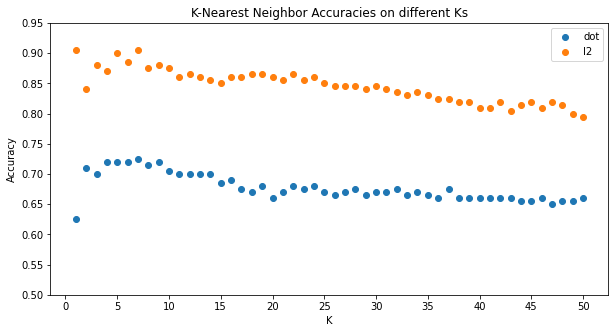

In [9]:
# Visualize the result
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)

x_axis = np.arange(1, num_ks+1, 1)
for i, metric in enumerate(metrics):
    ax.scatter(x_axis, result[metric], label = metric)

ax.set(title="K-Nearest Neighbor Accuracies on different Ks")
ax.set(xlabel='K', ylabel='Accuracy')
ax.set(xticks=np.arange(0, num_ks+1,5), yticks=np.arange(0.5,1.0,0.05))
ax.legend()
plt.show()